In [2]:
import sys
sys.path.insert(0, '/user/bnc2119/drd')
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib as mpl
from utils import *
from src.drd import AutoEncoder
from sklearn.datasets import fetch_openml
%load_ext autoreload
%autoreload 2

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-23 13:28:28.915791: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758648508.929203  105381 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758648508.933571  105381 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758648508.945200  105381 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once

In [3]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Prefix used in your table
prefix = 'config/teacher_config/'
teacher_col = prefix + 'teacher'

def _fmt(v):
    if pd.isna(v): 
        return None
    if isinstance(v, (int, np.integer)): 
        return str(v)
    if isinstance(v, float):
        return f"{v:.4g}" if not float(v).is_integer() else str(int(v))
    return str(v)

def make_label(row, param_cols):
    teacher = str(row[teacher_col])
    # include only params that are present on this row
    parts = []
    for c in sorted(param_cols):  # sorted for consistent ordering
        v = _fmt(row[c])
        if v is not None:
            key = c.split('/')[-1]  # e.g. "t_n_neighbors", "min_dist", ...
            parts.append(f"{key}={v}")
    return f"{teacher}({', '.join(parts)})" if parts else teacher


In [3]:
data = pd.read_csv("~/drd/gene_cancer/data.csv")
data.drop(columns=["Unnamed: 0"], inplace=True)
labs = pd.read_csv("~/drd/gene_cancer/labels.csv", index_col=0)

X = StandardScaler().fit_transform(data)
X.shape
# X_tsne_ls = {}
# for perp in [10, 20, 30, 40, 50, 60]:
#     tsne = TSNE(n_components=2, 
#                 perplexity=perp,
#                 init='random',)
#     X_tsne = tsne.fit_transform(X)
#     X_tsne_ls[perp] = X_tsne

# fig, axes = plt.subplots(2, 3, figsize=(10, 6))
# for p, ax in zip(X_tsne_ls.keys(), axes.flatten()):
#     sns.scatterplot(x = X_tsne_ls[p][:, 0], y= X_tsne_ls[p][:, 1], alpha=0.8, hue=labs['Class'], ax = ax)
#     ax.set_title(f'Perplexity: {p}', fontsize='small')
#     ax.legend(fontsize='xx-small')

# fig.suptitle('t-SNE Visualization of RNA-Seq PANCAN dataset')
# plt.tight_layout()

(801, 20531)

In [14]:
ground_truth_recon = []
for seed in range(10):
    X, _ = load_and_split("mnist", test_size=1, seed=seed, labels=False)
    for c in range(2, 21):
        pca = PCA(n_components=c).fit(X)
        X_hat = pca.inverse_transform(pca.transform(X))
        per_sample_mse = ((X - X_hat)**2).mean(axis=1)
        ground_truth_recon.append({"seed": seed, 
                                   "teacher_cfg": f'pca(n_components={c})', 
                                   "recon_loss": per_sample_mse.mean()})

In [ ]:
analysis = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/verify_mnist_pca.csv')
param_cols = [c for c in analysis.columns if c.startswith(prefix) and c != teacher_col]
analysis['teacher_cfg'] = analysis.apply(make_label, param_cols = param_cols, axis=1)

analysis2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/verify_mnist_pca_v2.csv')
param_cols = [c for c in analysis2.columns if c.startswith(prefix) and c != teacher_col]
analysis2['teacher_cfg'] = analysis2.apply(make_label, param_cols = param_cols, axis=1)
gt_recon = pd.DataFrame(ground_truth_recon)

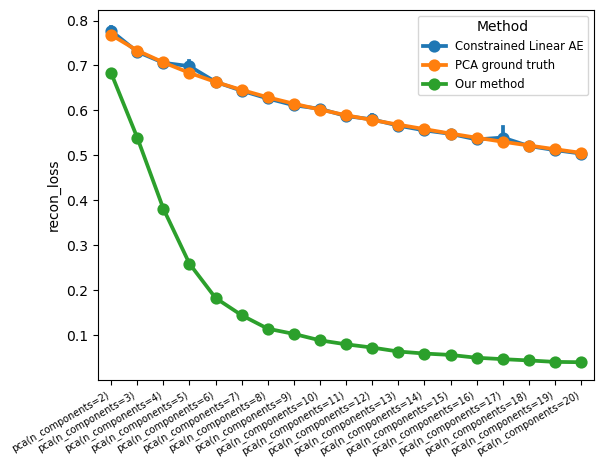

In [17]:
sns.pointplot(data=analysis, x='teacher_cfg', y='recon_loss', label="Constrained Linear AE")
sns.pointplot(data=gt_recon, x='teacher_cfg', y='recon_loss', label="PCA ground truth")
sns.pointplot(data=analysis2, x='teacher_cfg', y='recon_loss', label="Our method")
plt.xticks(rotation=30, fontsize=7, ha='right')
plt.xlabel("")
plt.legend(title="Method", fontsize='small')
plt.show()

In [4]:
def plot_orig_vs_recon(orig_4d, recon_4d, digits, title):
    C = len(digits)
    fig, axes = plt.subplots(2, C, figsize=(1.4*C, 3.0), constrained_layout=True)
    for j, d in enumerate(digits):
        axes[0, j].imshow(orig_4d[j, 0], cmap="gray", vmin=0, vmax=1)
        axes[0, j].set_title(str(d), fontsize=9)
        axes[0, j].axis("off")
        axes[1, j].imshow(recon_4d[j, 0], cmap="gray", vmin=0, vmax=1)
        axes[1, j].axis("off")
    fig.suptitle(title, fontsize=12)
    plt.show()
    plt.close(fig)
def load_trained_ae(ckpt_path, input_dim):
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=2,
        hidden_dims=[1000, 1000, 1000, 1000, 1000],
        activation=torch.nn.SELU,            # match training!
        bottleneck_activation=None
    )

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model


In [68]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
data = mnist.data.values[:1000, :]
labs = mnist.target.values[:1000]
scaler = StandardScaler()
scaler.fit(data)

base_dir = "/user/bnc2119/drd/results/chkpt/"
band_idx = 0

digits = list(range(10))
y_all = labs.astype(int)  
sel_idx = [np.where(y_all == d)[0][3] for d in digits]
X_sel = scaler.transform(data[sel_idx, :].astype(np.float32))

chkpt_ls, recon_ls, param_ls = [], [], []

for variant, ckpt in find_band_checkpoints(base_dir, band_idx):
    fam, param = variant_to_family_and_param(variant)
    chkpt_ls.append(ckpt)
    param_ls.append(param)
    model = load_trained_ae(ckpt, input_dim=data.shape[1])
    X_recon = model(torch.tensor(X_sel, dtype=torch.float32))[0].detach().numpy()
    X_recon_raw = scaler.inverse_transform(X_recon) 
    recon_ls.append(np.mean((X_sel - X_recon)**2))


encoder layers: [Linear(in_features=784, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=100, bias=True)]
decoder layers: [Linear(in_features=100, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=784, bias=True)]
loaded params: 24 | missing=0 | unexpected=0
encoder layers: [Linear(in_features=784, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_

In [69]:
np.argmin(recon_ls), np.min(recon_ls), np.argmax(recon_ls), np.max(recon_ls)

(np.int64(0), np.float32(0.19991073), np.int64(1), np.float32(0.2802617))

In [51]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
data = mnist.data.values[:10000, :]
labs = mnist.target.values[:10000]
scaler = StandardScaler()
scaler.fit(data)

base_dir = "/user/bnc2119/drd/results/chkpt/mnist"
band_idx = 0

digits = list(range(10))
y_all = labs.astype(int)  
sel_idx = [np.where(y_all == d)[0][3] for d in digits]
X_sel = scaler.transform(data[sel_idx, :].astype(np.float32))

chkpt_ls, recon_ls, param_ls = [], [], []

for variant, ckpt in find_band_checkpoints(base_dir, band_idx):
    fam, param = variant_to_family_and_param(variant)
    if fam == "umap":
        print(param)
        chkpt_ls.append(ckpt)
        param_ls.append(param)
        model = load_trained_ae(ckpt, input_dim=data.shape[1])
        X_recon = model(torch.tensor(X_sel, dtype=torch.float32))[0].detach().numpy()
        X_recon_raw = scaler.inverse_transform(X_recon) 
        recon_ls.append(np.mean((X_sel - X_recon)**2))


1000.0
encoder layers: [Linear(in_features=784, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=2, bias=True)]
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=784, bias=True)]
loaded params: 24 | missing=0 | unexpected=0
112.0
encoder layers: [Linear(in_features=784, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1

In [ ]:
model = load_trained_ae(chkpt_ls[np.argmin(recon_ls)], input_dim=data.shape[1])
X_recon = model(torch.tensor(X_sel, dtype=torch.float32))[0].detach().numpy()
X_recon_raw = scaler.inverse_transform(X_recon) 
plot_orig_vs_recon(X_sel.reshape(-1, 1, 28, 28),
                   X_recon_raw.reshape(-1, 1, 28, 28),
                   digits,
                   title = f"{fam} (param={param_ls[np.argmin(recon_ls)]})")

model = load_trained_ae(chkpt_ls[np.argmax(recon_ls)], input_dim=data.shape[1])
X_recon = model(torch.tensor(X_sel, dtype=torch.float32))[0].detach().numpy()
X_recon_raw = scaler.inverse_transform(X_recon) 
plot_orig_vs_recon(X_sel.reshape(-1, 1, 28, 28),
                   X_recon_raw.reshape(-1, 1, 28, 28),
                   digits,
                   title = f"{fam} (param={param_ls[np.argmax(recon_ls)]})")

In [6]:
X, _, y, _ = load_and_split("gene_cancer", test_size=1, labels=True)
Z, _ = get_teacher_embeddings("umap", X, X_test=None, n_neighbors=15, min_dist=0.1, random_state=0)

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


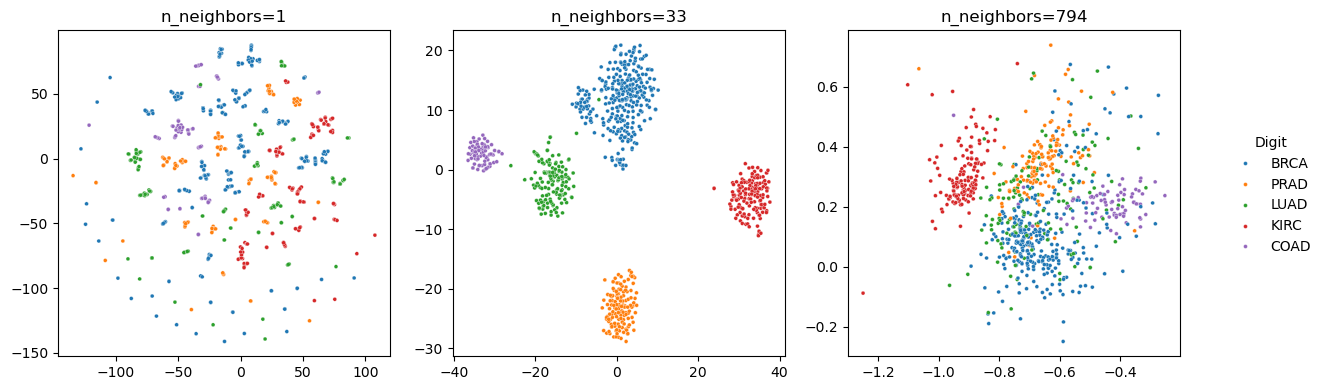

In [10]:
X, _, y, _ = load_and_split("gene_cancer", test_size=1, labels=True)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for idx, n in enumerate([1, 33, 794]):
    Z, _ = get_teacher_embeddings("tsne", X, X_test=None, perplexity=n, learning_rate=50)

    # show a legend only on the first axes so we can harvest handles/labels
    show_leg = (idx == 0)
    sns.scatterplot(
        x=Z[:, 0], y=Z[:, 1], hue=y['Class'], ax=axes[idx],
        legend='full' if show_leg else False, s=8
    )
    axes[idx].set_title(f"n_neighbors={n}")

# grab handles/labels from the first axes and remove its legend
handles, labels = axes[0].get_legend_handles_labels()
if getattr(axes[0], "legend_", None) is not None:
    axes[0].legend_.remove()

# make one shared legend for the whole figure
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(1.02, 0.5),
    frameon=False, title='Digit'
)

fig.tight_layout()
plt.show()

In [6]:
svm_train_acc, svm_test_acc = [], []
lr_train_acc, lr_test_acc = [], []
for perp in np.unique(np.logspace(0, 2.9, 20).astype(int)):
    Z, _ = get_teacher_embeddings("tsne", X, X_test=None, perplexity=perp, learning_rate=50)
    svm = SVC().fit(Z, y.__array__())
    lr = LogisticRegression().fit(Z, y.__array__())
    svm_train_acc.append(svm.score(Z, y.__array__()))
    lr_train_acc.append(lr.score(Z, y.__array__()))

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.

/tmp/ipykernel_97960/1731340057.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=8, ha='right')
/tmp/ipykernel_97960/1731340057.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=8, ha='right')


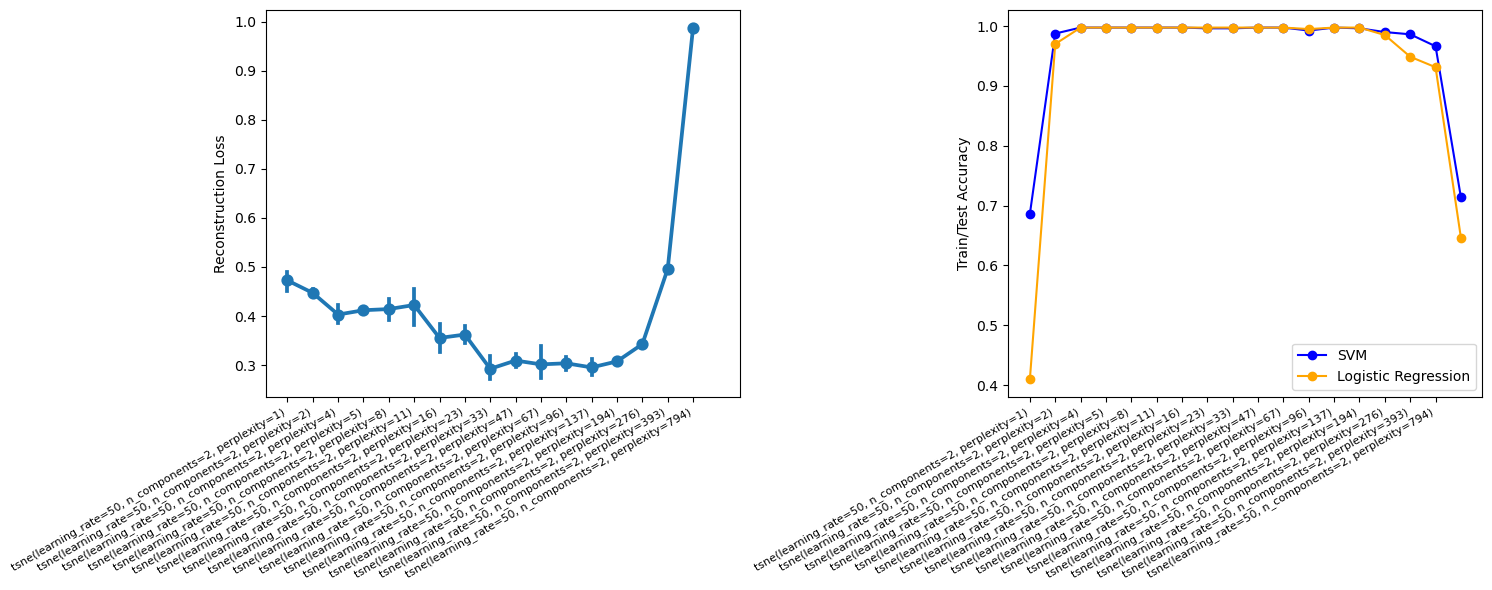

In [7]:
analysis = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/gene_cancer_tsne.csv')
analysis = analysis[analysis['distill_loss'] <= 9e-9]
param_cols = [c for c in analysis.columns if c.startswith(prefix) and c != teacher_col]
analysis['teacher_cfg'] = analysis.apply(make_label, param_cols = param_cols, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)
sns.pointplot(data=analysis, x='teacher_cfg', y='recon_loss', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=8, ha='right')
axes[1].plot(svm_train_acc, marker='o', label='SVM', color='blue')
axes[1].plot(lr_train_acc, marker='o', label='Logistic Regression', color='orange')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=8, ha='right')
axes[1].set_ylabel("Train/Test Accuracy")
axes[0].set_ylabel("Reconstruction Loss")
axes[0].set_xlabel("")
axes[1].legend()
plt.tight_layout()
plt.show()

In [26]:
Z_ls = []
for idx, n in enumerate([2, 6, 18, 54, 233, 1000]):
    Z, _ = get_teacher_embeddings("umap", X, X_test=None, n_neighbors=n, min_dist=0.1, random_state=0)
    Z_ls.append(Z)

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 296 with accuracies 
[3.68107527e-14 5.56315988e-05 1.93812288e-05 2.76110344e-05]
not reaching the requested tolerance 2.7865171432495117e-05.
Use iteration 267 instead with accuracy 
1.68540186680902e-05.

  _, diffusion_map = lobpcg(
/user/bnc2119/.con

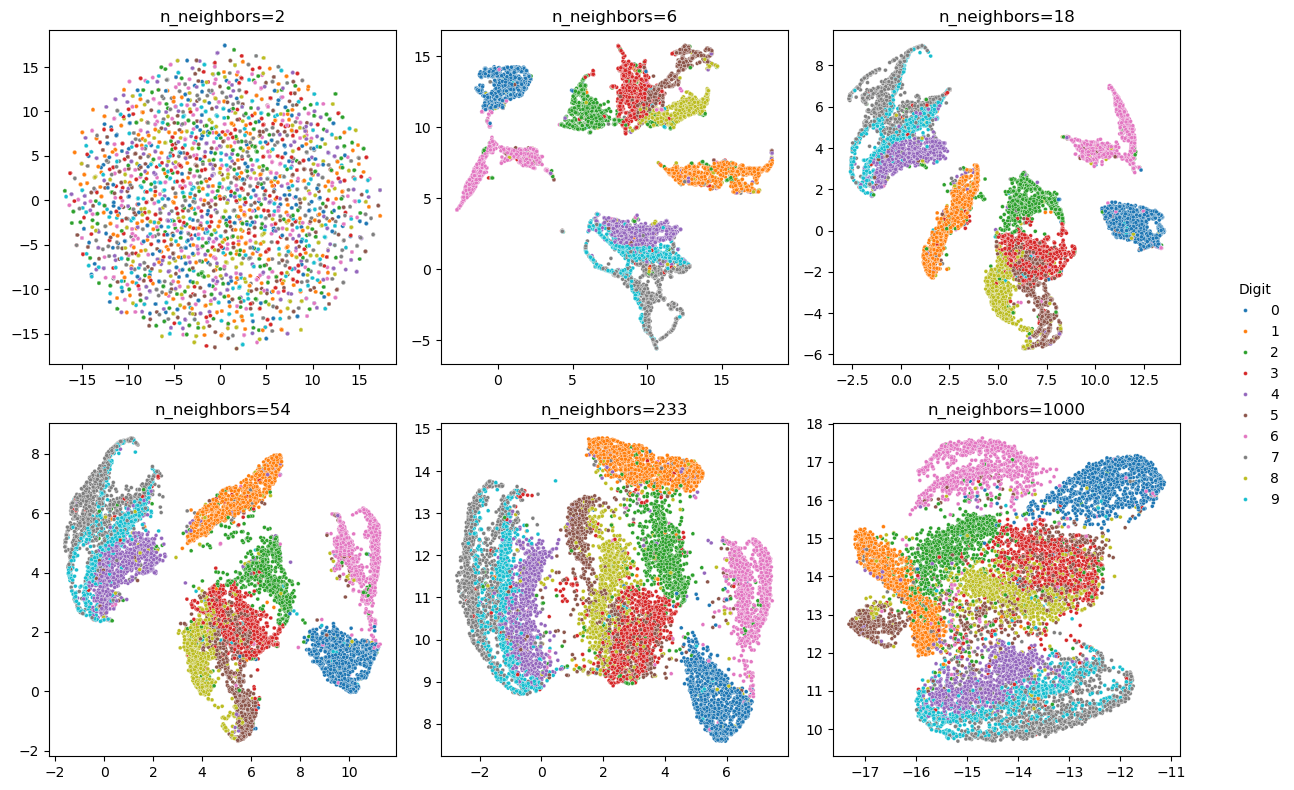

In [29]:
X, _, y, _ = load_and_split("mnist", test_size=1, labels=True)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes_flat = axes.flatten()
# Z_ls = []
for idx, n in enumerate([2, 6, 18, 54, 233, 1000]):
    Z = Z_ls[idx]
    # show a legend only on the first axes so we can harvest handles/labels
    show_leg = (idx == 0)
    sns.scatterplot(
        x=Z[:, 0], y=Z[:, 1], hue=y, ax=axes_flat[idx],
        legend='full' if show_leg else False, s=8
    )
    axes_flat[idx].set_title(f"n_neighbors={n}")

# grab handles/labels from the first axes and remove its legend
handles, labels = axes_flat[0].get_legend_handles_labels()
if getattr(axes_flat[0], "legend_", None) is not None:
    axes_flat[0].legend_.remove()

# make one shared legend for the whole figure
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(1.02, 0.5),
    frameon=False, title='Digit'
)

fig.tight_layout()
plt.show()

In [ ]:
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.values[:10000, :]
y = mnist.target.values[:10000]
scaler = StandardScaler().fit(X)
X_transform = scaler.transform(X)
X_test = mnist.data.values[10000: 10100, :]
X_test_transform = scaler.transform(X_test)
y_test = mnist.target.values[10000: 10100]
svm_train_acc, svm_test_acc = [], []
lr_train_acc, lr_test_acc = [], []
rfc_train_acc, rfc_test_acc = [], []
for n_neighbor in np.unique(np.logspace(0, 3, 20).astype(int))[1:]:
    Z, Z_test = get_teacher_embeddings("umap", X_transform, X_test=X_test_transform, n_neighbors=n_neighbor)
    svm = SVC().fit(Z, y.__array__())
    lr = LogisticRegression().fit(Z, y.__array__())
    svm_train_acc.append(svm.score(Z, y.__array__()))
    svm_test_acc.append(svm.score(Z_test, y_test.__array__()))
    lr_train_acc.append(lr.score(Z, y.__array__()))
    lr_test_acc.append(lr.score(Z_test, y_test.__array__()))

In [22]:
analysis = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist_umap.csv')
param_cols = [c for c in analysis.columns if c.startswith(prefix) and c != teacher_col]
analysis['teacher_cfg'] = analysis.apply(make_label, param_cols = param_cols, axis=1)

/tmp/ipykernel_118018/2111339089.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=8, ha='right')
/tmp/ipykernel_118018/2111339089.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=8, ha='right')
/tmp/ipykernel_118018/2111339089.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


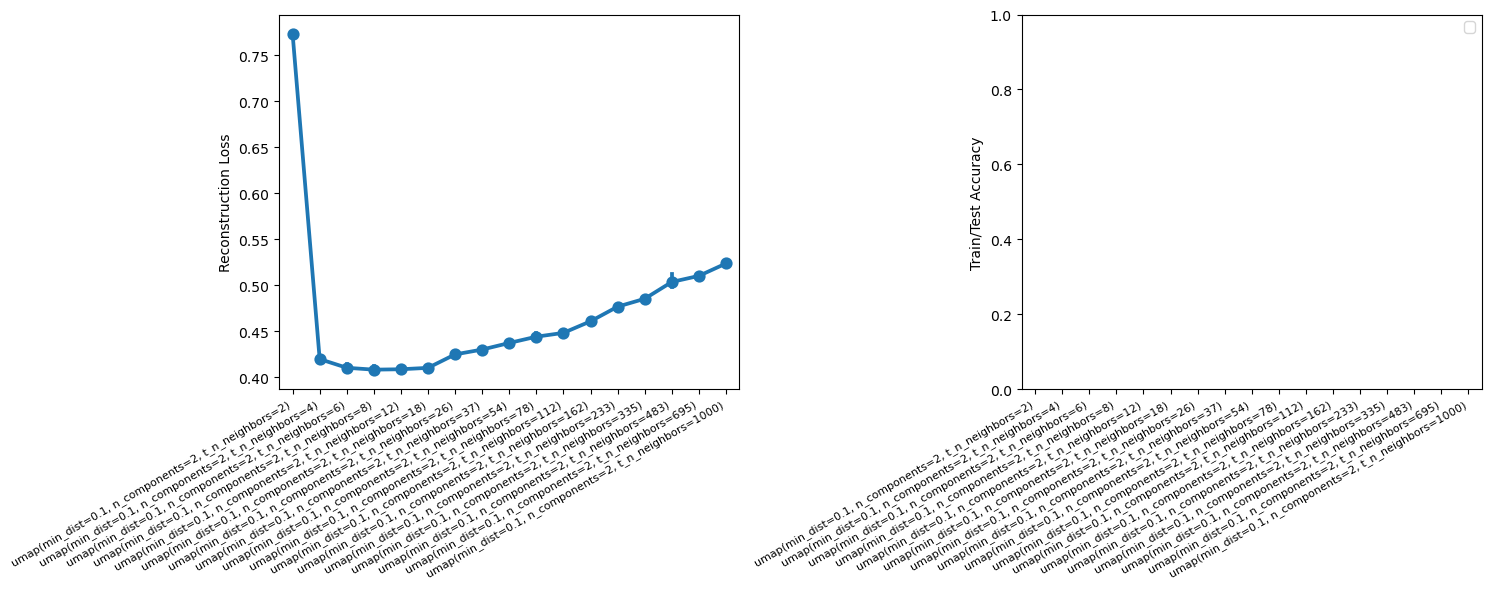

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)
sns.pointplot(data=analysis, x='teacher_cfg', y='recon_loss', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=8, ha='right')
# axes[1].plot(svm_train_acc, marker='o', label='SVM', color='blue')
# axes[1].plot(lr_train_acc, marker='o', label='Logistic Regression', color='orange')
# axes[1].plot(rfc_train_acc, marker='o', label='Random Forest')
# axes[1].plot(svm_test_acc, marker='o', label='Test SVM', linestyle='--', color='blue')
# axes[1].plot(lr_test_acc, marker='o', label='Test LR', linestyle='--', color='orange')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=8, ha='right')
axes[1].set_ylabel("Train/Test Accuracy")
axes[0].set_ylabel("Reconstruction Loss")
axes[0].set_xlabel("")
axes[1].legend()
plt.tight_layout()
plt.show()

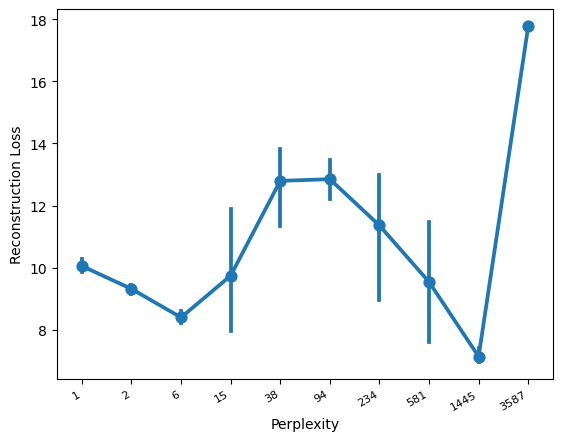

In [4]:
analysis = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_tsne.csv')
sns.pointplot(data=analysis, x='config/teacher_config/perplexity', y='recon_loss')
plt.xlabel("Perplexity")
plt.ylabel("Reconstruction Loss")
plt.xticks(rotation=30, fontsize=8, ha='right');

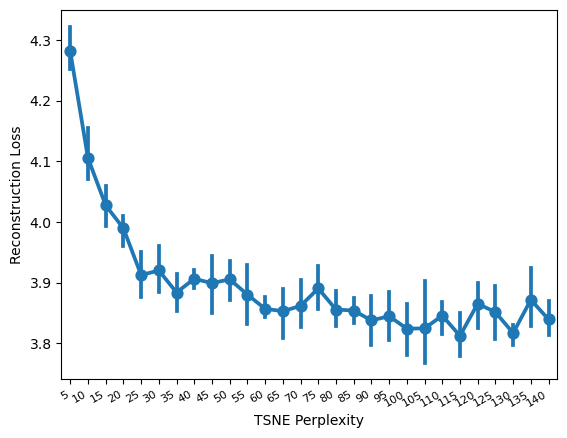

In [18]:
analysis = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/pbmc_tsne.csv')
analysis2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/pbmc_tsne2.csv')
analysis = pd.concat([analysis, analysis2], axis=0)
param_cols = [c for c in analysis.columns if c.startswith(prefix) and c != teacher_col]
analysis['teacher_cfg'] = analysis.apply(make_label, param_cols = param_cols, axis=1)
sns.pointplot(data=analysis, x='config/teacher_config/perplexity', y='recon_loss')
plt.xticks(rotation=30, fontsize=8, ha='right')
plt.xlabel("TSNE Perplexity")
plt.ylabel("Reconstruction Loss");

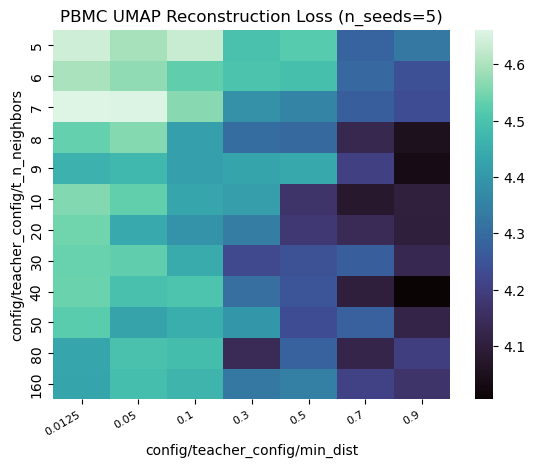

In [36]:
analysis = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/pbmc_umap.csv')
analysis2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/pbmc_umap2.csv')
analysis = pd.concat([analysis, analysis2])
subset = analysis[['config/teacher_config/t_n_neighbors', 'config/teacher_config/min_dist', 'recon_loss']]
subset_agg = subset.groupby(['config/teacher_config/t_n_neighbors', 'config/teacher_config/min_dist']).mean().reset_index()
sns.heatmap(data = subset_agg.pivot(index='config/teacher_config/t_n_neighbors', columns='config/teacher_config/min_dist', values='recon_loss'), annot=False, fmt=".4f", cmap="mako")
plt.xticks(rotation=30, fontsize=8, ha='right')
plt.title("PBMC UMAP Reconstruction Loss (n_seeds=5)");

In [1]:
columnss = ['distill_loss', 'recon_loss', 'time_total_s', "teacher_cfg", 'training_iteration']

In [3]:
base_dir = "/user/bnc2119/drd"
rows = evaluate_band(
    base_dir=base_dir,
    band_idx=0,
    analysis_filepath='gene_cancer_tsne.csv',
    tuning_param='learning_rate',
)

# 4) Make the figures
# plot_recon_vs_distill(rows, title="Recon vs Distill (Band 0)")
# plot_recon_bar_at_band(rows, title="Recon at Band 0 across families")
# plt.show()

## Gene cancer dataset
<!-- Red arrow = No activation, Blue arrow = ReLU activation -->

<!-- ![](/user/bnc2119/drd/gene_cancer_architecture.png) -->

In [7]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/gene_cancer_from_scratch.csv')
analysis_from_scratch2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/gene_cancerfrom_scratch2.csv')
analysis_from_scratch = pd.concat([analysis_from_scratch, analysis_from_scratch2], ignore_index=True)
# analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.training_iteration < 100]
param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/gene_cancer_from_pretrained.csv')
analysis_from_pretrained2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/gene_cancer_from_pretrained2.csv')
analysis_from_pretrained = pd.concat([analysis_from_pretrained, analysis_from_pretrained2], ignore_index=True)
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.training_iteration < 100]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
analysis = pd.concat([df_scratch, df_pretrained], ignore_index=True)

/tmp/ipykernel_118885/3597221223.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_118885/3597221223.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'


/tmp/ipykernel_118885/2490112003.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
/tmp/ipykernel_118885/2490112003.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')


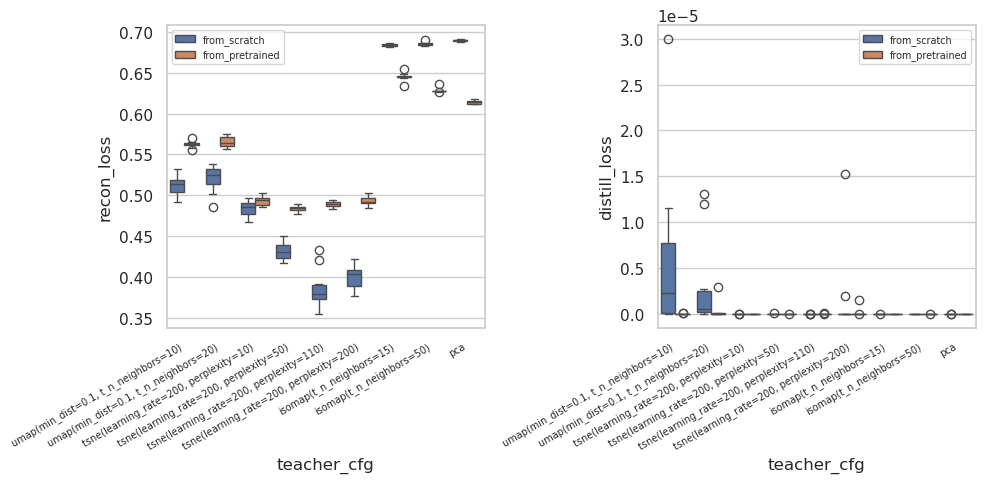

In [8]:
present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0), 'teacher_cfg']
analysis_both_pc = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both_pc, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both_pc, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

## Wine data
<!-- Red arrow = No activation, Green arrow = SELU activation

![](/user/bnc2119/drd/wine_architecture.png) -->

In [4]:
analysis = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/wine.csv')
df = analysis[columnss]
df = df.sort_values(by='recon_loss')
pd.set_option('display.float_format', '{:.6e}'.format)
(df
  .style
  .background_gradient(subset=["distill_loss","recon_loss","time_total_s"],
                       cmap="viridis")
  .format({"distill_loss":"{:.6e}"})
  .set_caption("Hyperparameter Results"))

,distill_loss,recon_loss,time_total_s,config/teacher_config/teacher,config/teacher_config/t_n_neighbors,config/teacher_config/min_dist,config/teacher_config/perplexity,config/teacher_config/learning_rate
7,2.261013e-10,0.099482,1970.469585,tsne,nan,nan,30.000000,300.000000
9,1.173212e-09,0.101209,1895.327933,tsne,nan,nan,50.000000,300.000000
6,2.158119e-10,0.109476,1891.452716,tsne,nan,nan,30.000000,200.000000
8,6.889334e-10,0.109478,1972.391455,tsne,nan,nan,50.000000,200.000000
2,9.253214e-09,0.136924,3780.565160,umap,15.000000,0.010000,nan,nan
1,5.260019e-09,0.138552,3778.257993,umap,10.000000,0.100000,nan,nan
0,1.075634e-08,0.139695,3773.828948,umap,10.000000,0.010000,nan,nan
4,6.128851e-09,0.140989,3781.976525,umap,20.000000,0.010000,nan,nan
3,4.609693e-09,0.144554,3781.753117,umap,15.000000,0.100000,nan,nan
5,4.939715e-09,0.151676,3780.990306,umap,20.000000,0.100000,nan,nan


## MNIST data

<!-- Red arrow = No activation, Green arrow = SELU activation

![](/user/bnc2119/drd/mnist_architecture.png) -->

In [16]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/rot_mnist_from_scratch.csv')
# analysis_from_scratch2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist_from_scratch2.csv')
# analysis_from_scratch = pd.concat([analysis_from_scratch, analysis_from_scratch2], ignore_index=True)
# analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.training_iteration < 100]
analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.distill_loss < 0.1]
param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/rot_mnist_from_pretrained.csv')
# analysis_from_pretrained2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist_from_pretrained2.csv')
# analysis_from_pretrained = pd.concat([analysis_from_pretrained, analysis_from_pretrained2], ignore_index=True)
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.training_iteration < 100]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
analysis = pd.concat([df_scratch, df_pretrained], ignore_index=True)

/tmp/ipykernel_110985/3406543892.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_110985/3406543892.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'


/tmp/ipykernel_110985/3138892948.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
/tmp/ipykernel_110985/3138892948.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')


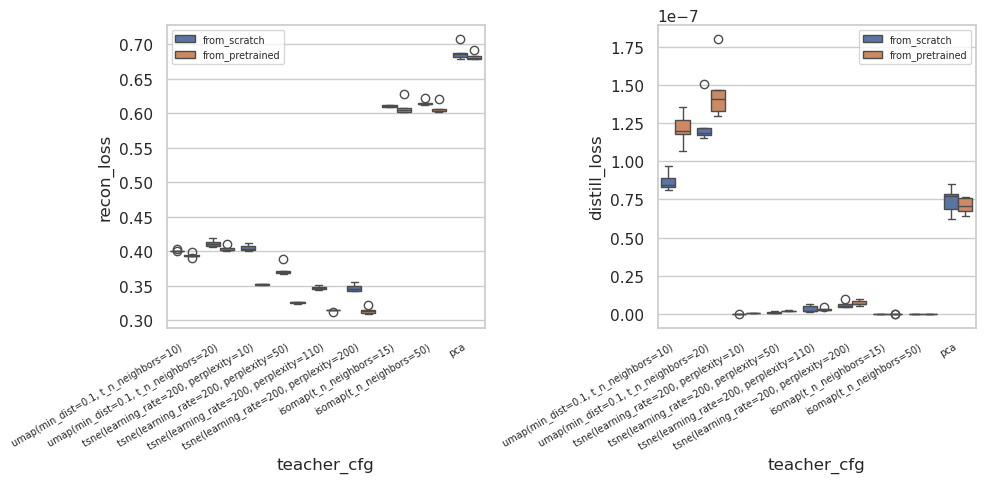

In [18]:
present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0), 'teacher_cfg']
analysis_both = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

/tmp/ipykernel_114026/3873201064.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_114026/3873201064.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'
/tmp/ipykernel_114026/3873201064.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right'

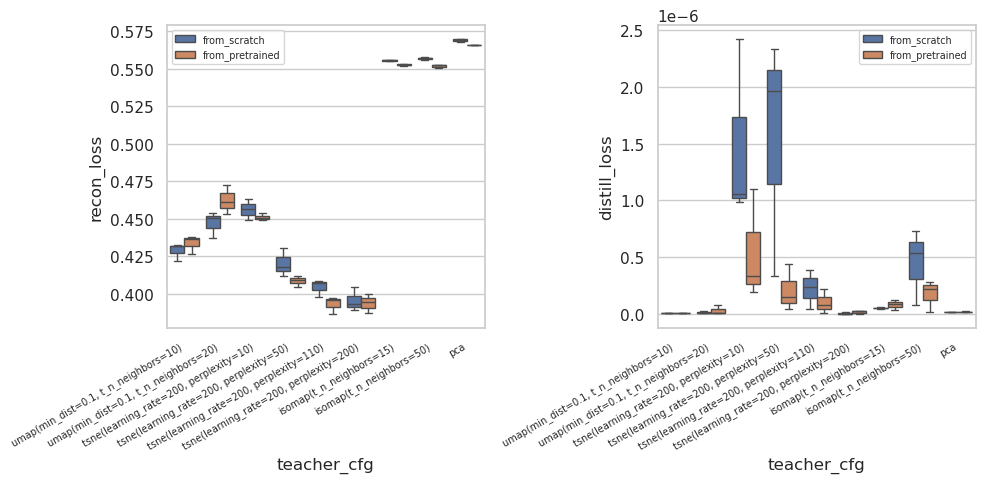

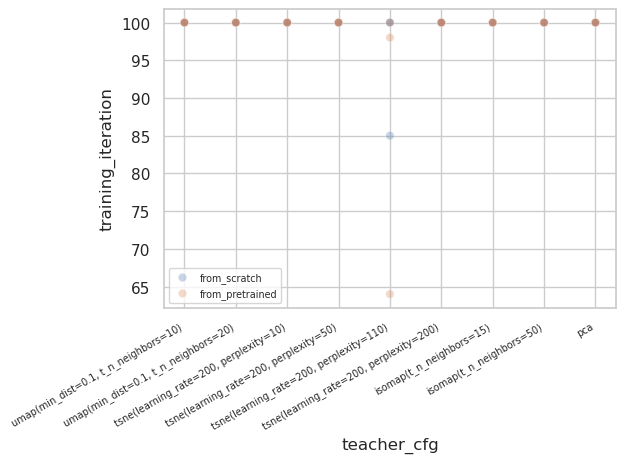

In [55]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist1k_from_scratch.csv')
# analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.training_iteration < 100]
param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist1k_from_pretrained.csv')
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.training_iteration < 100]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
analysis = pd.concat([df_scratch, df_pretrained], ignore_index=True)

present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0), 'teacher_cfg']
analysis_both = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

sns.scatterplot(data=analysis_both, x = 'teacher_cfg', y = 'training_iteration', hue = 'setting', alpha=0.3)
plt.xticks(rotation=30, fontsize=7, ha='right')
plt.legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

## Single Cell data

<!-- ![](/user/bnc2119/drd/single_cell_architecture.png) -->

In [21]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_scratch.csv')
analysis_from_scratch2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_scratch2.csv')
analysis_from_scratch = pd.concat([analysis_from_scratch, analysis_from_scratch2], ignore_index=True)
# analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.training_iteration < 100]
param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_pretrained.csv')
analysis_from_pretrained2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_pretrained2.csv')
analysis_from_pretrained = pd.concat([analysis_from_pretrained, analysis_from_pretrained2], ignore_index=True)
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.training_iteration < 100]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
analysis = pd.concat([df_scratch, df_pretrained], ignore_index=True)

/tmp/ipykernel_118885/1430140271.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_118885/1430140271.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'


/tmp/ipykernel_118885/2818806538.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
/tmp/ipykernel_118885/2818806538.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')


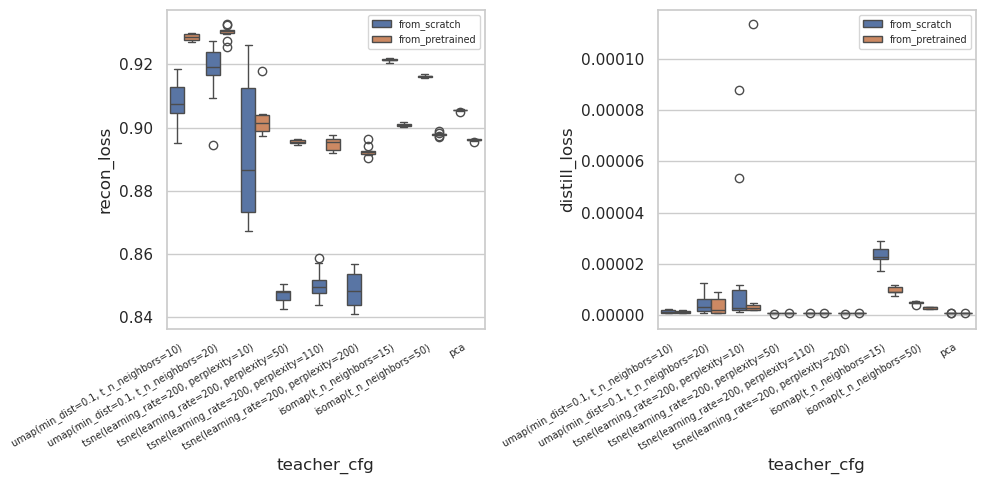

In [23]:
present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0), 'teacher_cfg']
analysis_both_sc = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

/tmp/ipykernel_118885/403697329.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
/tmp/ipykernel_118885/403697329.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')


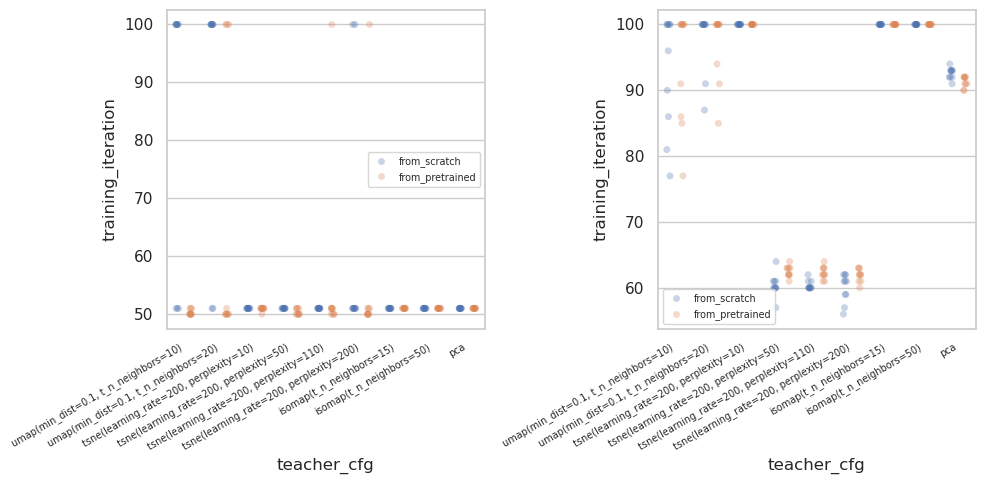

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.stripplot(data=analysis_both_pc, x = 'teacher_cfg', y = 'training_iteration', hue = 'setting', alpha=0.3, ax = axes[0], dodge=True)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.stripplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'training_iteration', hue = 'setting',alpha=0.3, ax = axes[1], dodge=True)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

/tmp/ipykernel_110985/3152137547.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_110985/3152137547.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'
/tmp/ipykernel_110985/3152137547.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

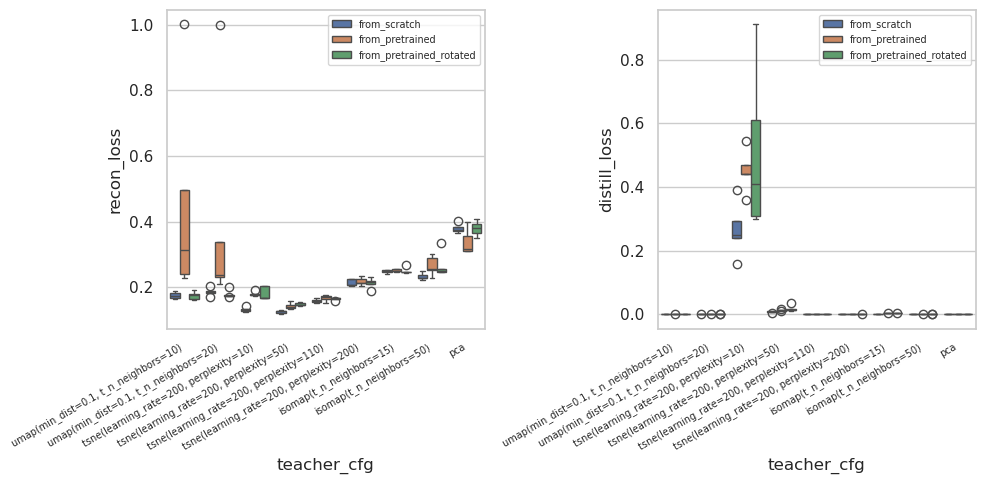

In [6]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/diabetes_from_scratch.csv')
# analysis_from_scratch2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/diabetes_from_scratch2.csv')
# analysis_from_scratch = pd.concat([analysis_from_scratch, analysis_from_scratch2], ignore_index=True)

param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/diabetes_from_pretrained.csv')
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.distill_loss < 0.01]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

analysis_from_pretrained_rot = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/rot_diabetes_from_pretrained.csv')
analysis_from_pretrained_rot = analysis_from_pretrained_rot[analysis_from_pretrained_rot.distill_loss < 1]
param_cols = [c for c in analysis_from_pretrained_rot.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained_rot['teacher_cfg'] = analysis_from_pretrained_rot.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained_rot = analysis_from_pretrained_rot[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
df_pretrained_rot['setting'] = 'from_pretrained_rotated'
analysis = pd.concat([df_scratch, df_pretrained, df_pretrained_rot], ignore_index=True)

present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0) & (present['from_pretrained_rotated'] > 0), 'teacher_cfg']
analysis_both_sc = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()

plt.show()